In [1]:
import pandas as pd

df_test = pd.read_csv('ASTRO-PH/CA-AstroPh-test.txt')
df_train = pd. read_csv('ASTRO-PH/CA-AstroPh-train.txt')


df_train.head()

,70718 78179
0,24699 40495
1,39789 102116
2,26590 28706
3,102198 123909
4,54796 73759


In [2]:
df_test.head()
print(len(df_train), len(df_test))

178442 19666


In [3]:
#remove empty rows
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print(len(df_train), len(df_test))

#remove duplicates
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)

print(len(df_train), len(df_test))

178442 19666
178442 19666


In [4]:
import networkx as nx
import random
import pandas as pd
from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC



def load_graph(edge_file):
    G = nx.read_edgelist(edge_file, nodetype=int)
    return G

def shortest_path_feature(G, u, v, max_distance=4):
    try:
        dist = nx.shortest_path_length(G, u, v)
        if dist <= max_distance and dist > 0:
            return 1 / dist
        else:
            return 0
    except nx.NetworkXNoPath:
        return 0

def compute_features(G, u, v):
    common_neighbors = len(list(nx.common_neighbors(G, u, v)))
    union = len(set(G.neighbors(u)).union(G.neighbors(v)))
    jaccard = common_neighbors / union if union != 0 else 0

    try:
        admic_adda = sum(1 / nx.log(G.degree(w)) for w in nx.common_neighbors(G, u, v))
    except:
        admic_adda = 0

    pref_attach = G.degree(u) * G.degree(v)
    # resource allocation index
    resource_allocation = sum(1 / G.degree(w) for w in nx.common_neighbors(G, u, v))
    
    #shortest path feature
    shortest_path = shortest_path_feature(G, u, v)
    return [common_neighbors, jaccard, admic_adda, pref_attach, resource_allocation]

G_train = load_graph('ASTRO-PH/CA-AstroPh-train.txt')
print("Nodes:", G_train.number_of_nodes())
print("Edges:", G_train.number_of_edges())


Nodes: 18616
Edges: 178443


In [5]:
G_test = load_graph('ASTRO-PH/CA-AstroPh-test.txt')
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())


Nodes: 11517
Edges: 19667


In [ ]:


def create_dataset(G, num_negative=None):
    edges = list(G.edges())
    non_edges = list(nx.non_edges(G))

    if num_negative is None:
        num_negative = len(edges)

    non_edges = random.sample(non_edges, num_negative)

    X = []
    y = []

    # Positive links (label = 1)
    for u, v in edges:
        X.append(compute_features(G, u, v))
        y.append(1)

    # Negative links (label = 0)
    for u, v in non_edges:
        X.append(compute_features(G, u, v))
        y.append(0)

    return pd.DataFrame(X), pd.Series(y)

X, y = create_dataset(G_train)
X_future, y_future = create_dataset(G_test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    # "SVM (RBF Kernel)": SVC(
    #     kernel="rbf",
    #     probability=True,
    #     class_weight="balanced"
    # )
}


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })


results_df = pd.DataFrame(results)
results_df.sort_values(by="F1", ascending=False, inplace=True)
print(results_df)



Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...
                 Model  Accuracy  Precision    Recall        F1
1        Random Forest  0.982754   0.989822  0.975539  0.982628
2    Gradient Boosting  0.982600   0.990014  0.975034  0.982467
0  Logistic Regression  0.977794   0.992946  0.962425  0.977448


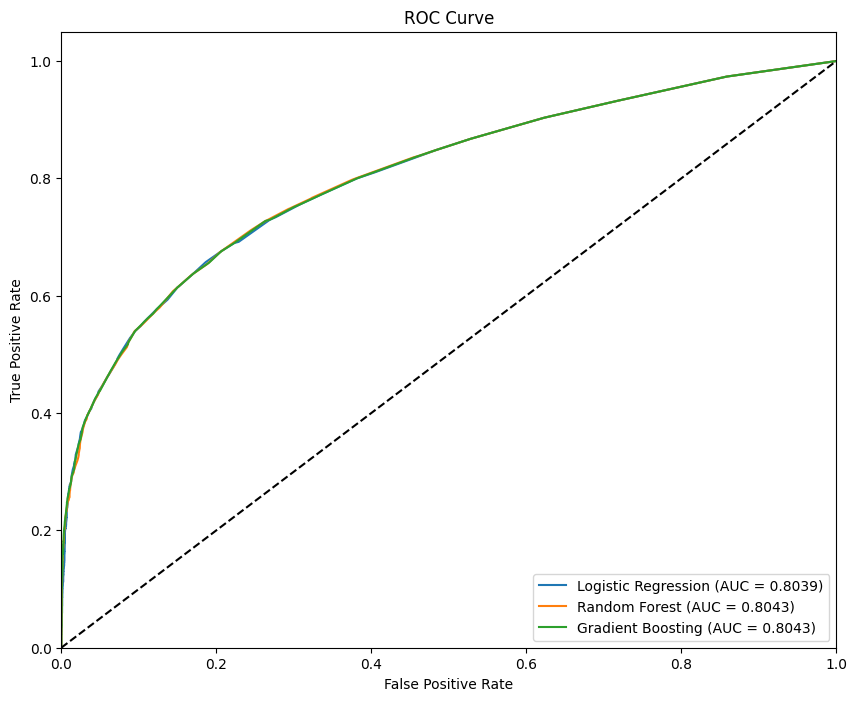

In [61]:
#plot the roc curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [8]:

E_train = set(G_train.edges())
E_test = set(G_test.edges())

E_new = set((u, v) for (u, v) in E_test if (u, v) not in E_train)
n = len(E_new)

print("Number of future edges (n):", n)


Number of future edges (n): 19667


In [12]:

candidates = []
# get 10 random non-edges for prediction
non_edges = list(nx.non_edges(G_train))
non_edges = random.sample(non_edges, min(10, len(non_edges)))

for u, v in non_edges:
    features = compute_features(G_train, u, v)
    score = model.predict_proba([features])[0][1]   # probability of link
    candidates.append((u, v, score))
candidates.sort(key=lambda x: x[2], reverse=True)
top_n = candidates[:n]

print("Top predicted links:")
for u, v, score in top_n:
    print(f"Link: ({u}, {v}), Score: {score:.4f}")

Top predicted links:
Link: (80577, 83092), Score: 0.0280
Link: (53682, 62610), Score: 0.0237
Link: (7072, 83188), Score: 0.0226
Link: (112609, 26840), Score: 0.0208
Link: (103519, 125226), Score: 0.0208
Link: (529, 51425), Score: 0.0208
Link: (74296, 24313), Score: 0.0178
Link: (6593, 122894), Score: 0.0178
Link: (70336, 82373), Score: 0.0178
Link: (116697, 88494), Score: 0.0178


In [62]:

import networkx as nx
from node2vec import Node2Vec


node2vec = Node2Vec(
    G,
    dimensions=128,
    walk_length=20,
    num_walks=10,
    workers=4
)

model = node2vec.fit(
    window=10,
    min_count=1
)


import numpy as np

def edge_embedding(u, v, model):
    emb_u = model.wv[str(u)]
    emb_v = model.wv[str(v)]
    return emb_u * emb_v


import random

def create_embedding_dataset(G, model, num_negative=None):
    X = []
    y = []

    edges = list(G.edges())
    non_edges = list(nx.non_edges(G))

    if num_negative is None:
        num_negative = len(edges)

    non_edges = random.sample(non_edges, num_negative)

    # Positive links
    for u, v in edges:
        X.append(edge_embedding(u, v, model))
        y.append(1)

    # Negative links
    for u, v in non_edges:
        X.append(edge_embedding(u, v, model))
        y.append(0)

    return np.array(X), np.array(y)

X, y = create_embedding_dataset(G, model)

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1", ascending=False, inplace=True)
print(results_df)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating walks (CPU: 4): 100%|██████████| 2/2 [00:00<00:00,  2.01it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...
                 Model  Accuracy  Precision    Recall        F1
2    Gradient Boosting  0.734599   0.765847  0.675763  0.717990
5    Gradient Boosting  0.734599   0.765847  0.675763  0.717990
1        Random Forest  0.732904   0.776348  0.654237  0.710081
4        Random Forest  0.732904   0.776348  0.654237  0.710081
0  Logistic Regression  0.722820   0.844380  0.546271  0.663373
3  Logistic Regression  0.722820   0.844380  0.546271  0.663373


In [69]:
import numpy as np
import torch
from torch_geometric.utils import from_networkx
from torch_geometric.transforms import RandomLinkSplit

# Build simple but informative node features from graph structure.
node_list = list(G.nodes())
degree = np.array([G.degree(n) for n in node_list], dtype=np.float32)
clustering = np.array([nx.clustering(G, n) for n in node_list], dtype=np.float32)
pagerank_dict = nx.pagerank(G, alpha=0.85)
pagerank = np.array([pagerank_dict[n] for n in node_list], dtype=np.float32)

feat = np.stack([np.log1p(degree), clustering, pagerank], axis=1)
feat = (feat - feat.mean(axis=0)) / (feat.std(axis=0) + 1e-9)

data = from_networkx(G)
data.x = torch.tensor(feat, dtype=torch.float)

transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=True,
    split_labels=False,
    neg_sampling_ratio=1.0,
 )
train_data, val_data, test_data = transform(data)

print("Node feature shape:", data.x.shape)
print("Train edges:", train_data.edge_label_index.size(1))
print("Val edges:", val_data.edge_label_index.size(1))
print("Test edges:", test_data.edge_label_index.size(1))

Node feature shape: torch.Size([11517, 3])
Train edges: 27536
Val edges: 3932
Test edges: 7866


In [72]:
import copy
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score

torch.manual_seed(42)

class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.dropout = dropout

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

def evaluate_auc(model, split_data):
    model.eval()
    with torch.no_grad():
        logits = model(split_data.x, split_data.edge_index, split_data.edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
        labels = split_data.edge_label.cpu().numpy()
    return roc_auc_score(labels, probs)

model = GNN(train_data.num_node_features, 64, dropout=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

best_val_auc = 0.0
best_state = None
patience = 30
patience_counter = 0

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()

    train_logits = model(train_data.x, train_data.edge_index, train_data.edge_label_index)
    loss = F.binary_cross_entropy_with_logits(train_logits, train_data.edge_label.float())
    loss.backward()
    optimizer.step()

    val_auc = evaluate_auc(model, val_data)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Val AUC {val_auc:.4f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_auc = evaluate_auc(model, test_data)
print("Best Val ROC-AUC:", best_val_auc)
print("GNN Test ROC-AUC:", test_auc)

Epoch 020 | Loss 0.6286 | Val AUC 0.6977
Epoch 040 | Loss 0.5301 | Val AUC 0.7083
Epoch 060 | Loss 0.5062 | Val AUC 0.7075
Epoch 080 | Loss 0.4915 | Val AUC 0.7047
Epoch 100 | Loss 0.4799 | Val AUC 0.7058
Epoch 120 | Loss 0.4716 | Val AUC 0.7057
Epoch 140 | Loss 0.4644 | Val AUC 0.7056
Epoch 160 | Loss 0.4632 | Val AUC 0.7090
Epoch 180 | Loss 0.4573 | Val AUC 0.7086
Epoch 200 | Loss 0.4527 | Val AUC 0.7127
Epoch 220 | Loss 0.4456 | Val AUC 0.7127
Epoch 240 | Loss 0.4444 | Val AUC 0.7120
Epoch 260 | Loss 0.4389 | Val AUC 0.7135
Epoch 280 | Loss 0.4373 | Val AUC 0.7128
Epoch 300 | Loss 0.4356 | Val AUC 0.7106
Best Val ROC-AUC: 0.7169839975411083
GNN Test ROC-AUC: 0.722618285470546
